# 07. Sparkov Cost-Sensitive Decisioning

This notebook converts calibrated fraud probabilities into **decision rules**.

A fraud model does not create business value merely by ranking risky transactions well.

A real fraud system must decide:

> At what point is the expected benefit of investigating or intervening greater than the expected cost of doing so?

## Main Research Question

> Do cost-sensitive decision rules improve proxy economic outcomes compared with a fixed 0.5 probability threshold?

## Decision Policies Compared

1. **Fixed threshold 0.5**
   - simple reference policy

2. **F1-maximizing threshold**
   - selected on Validation

3. **Proxy-cost-minimizing threshold**
   - selected on Validation

4. **Positive expected-benefit rule**
   - alert a transaction when its transaction-level expected benefit is positive

## Important Cost Interpretation

This project does **not** have actual bank loss, investigation cost, chargeback cost, or customer-friction cost data.

Therefore all economic quantities in this notebook are **illustrative proxy-cost assumptions**.

In particular:

- transaction `amt` is a proxy for potential fraud exposure
- `amt` is **not** actual realized bank loss
- review cost is assumed
- customer-friction cost is assumed
- intervention effectiveness is assumed

The goal is to demonstrate a defensible decision framework, not to claim actual bank savings.

## Cost Sensitivity

Because the true business costs are unknown, we evaluate several scenarios rather than relying on a single arbitrary number.

## Split Roles

- **Train** — fit preprocessing and fraud model
- **Calibration** — fit probability calibrators
- **Validation** — select imbalance strategy, calibration method, thresholds, and cost policy
- **Test** — remains locked

## Test Set Lock

No Test prediction or Test metric is generated in this notebook.

## 1. Import Libraries and Create Output Folders

This notebook is designed to run independently in Kaggle.

It recreates the earlier modeling pipeline so that the cost analysis is fully reproducible.

In [3]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    precision_recall_curve,
)

from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/figures", exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load and Clean the Sparkov Dataset

Expected Kaggle path:

`/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv`

The same basic cleaning rules are reused from the previous notebooks.

In [4]:
DATA_PATH = "/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv"

df = pd.read_csv(DATA_PATH)

df = df.drop(
    columns=[
        c for c in df.columns
        if c.lower().startswith("unnamed")
    ],
    errors="ignore"
)

df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"],
    errors="coerce"
)

df["dob"] = pd.to_datetime(
    df["dob"],
    errors="coerce"
)

df["merchant_clean"] = (
    df["merchant"]
    .astype(str)
    .str.replace(
        r"^fraud_",
        "",
        regex=True
    )
)

df = (
    df.sort_values(
        ["unix_time", "trans_num"]
    )
    .reset_index(drop=True)
)

assert df["unix_time"].is_monotonic_increasing

print("Shape:", df.shape)
print("Fraud rate:", df["is_fraud"].mean())

Shape: (1296675, 24)
Fraud rate: 0.005788651743883394


## 3. Recreate Current-Transaction Features

The cost experiment must not change the feature-engineering design.

We therefore reuse the same current-transaction features from the earlier notebooks.

In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 6371 * 2 * np.arcsin(np.sqrt(a))


df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype("int8")

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["age"] = (
    (df["trans_date_trans_time"] - df["dob"]).dt.days
    / 365.25
)

df["distance_home_to_merchant_km"] = haversine_km(
    df["lat"],
    df["long"],
    df["merch_lat"],
    df["merch_long"]
)

print("Current-transaction features created.")

Current-transaction features created.


## 4. Recreate Leakage-Safe Past-Only Features

The same historical feature design from Notebook 04 is reused.

Every historical feature excludes the current transaction and uses only earlier transaction information.

No historical fraud labels are used.

In [6]:
def add_past_only_features(data):
    data = (
        data.sort_values(
            ["unix_time", "trans_num"]
        )
        .reset_index(drop=True)
        .copy()
    )

    card_group = data.groupby(
        "cc_num",
        sort=False
    )

    data["card_tx_count_before"] = (
        card_group.cumcount()
    )

    data["card_has_history"] = (
        data["card_tx_count_before"] > 0
    ).astype("int8")

    data["card_prev_unix_time"] = (
        card_group["unix_time"].shift(1)
    )

    data["card_time_since_prev_hours"] = (
        data["unix_time"]
        - data["card_prev_unix_time"]
    ) / 3600.0

    data["_amt_sq"] = data["amt"] ** 2

    data["_card_amt_sum_before"] = (
        card_group["amt"].cumsum()
        - data["amt"]
    )

    data["_card_amt_sq_sum_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_amt_sq"].cumsum()
        - data["_amt_sq"]
    )

    previous_count = (
        data["card_tx_count_before"]
        .replace(0, np.nan)
    )

    data["card_amt_mean_before"] = (
        data["_card_amt_sum_before"]
        / previous_count
    )

    previous_second_moment = (
        data["_card_amt_sq_sum_before"]
        / previous_count
    )

    previous_variance = (
        previous_second_moment
        - data["card_amt_mean_before"] ** 2
    ).clip(lower=0)

    data["card_amt_std_before"] = (
        np.sqrt(previous_variance)
    )

    data["card_amt_ratio_to_mean"] = (
        data["amt"]
        / data[
            "card_amt_mean_before"
        ].replace(0, np.nan)
    )

    data["card_amt_zscore_before"] = (
        (
            data["amt"]
            - data["card_amt_mean_before"]
        )
        / data[
            "card_amt_std_before"
        ].replace(0, np.nan)
    )

    data["card_merchant_pair_count_before"] = (
        data.groupby(
            ["cc_num", "merchant_clean"],
            sort=False
        ).cumcount()
    )

    data["card_new_merchant"] = (
        data[
            "card_merchant_pair_count_before"
        ] == 0
    ).astype("int8")

    data["_merchant_first_for_card"] = (
        data[
            "card_merchant_pair_count_before"
        ] == 0
    ).astype("int8")

    data["card_distinct_merchants_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_merchant_first_for_card"].cumsum()
        - data["_merchant_first_for_card"]
    )

    data["card_category_pair_count_before"] = (
        data.groupby(
            ["cc_num", "category"],
            sort=False
        ).cumcount()
    )

    data["card_new_category"] = (
        data[
            "card_category_pair_count_before"
        ] == 0
    ).astype("int8")

    data["_category_first_for_card"] = (
        data[
            "card_category_pair_count_before"
        ] == 0
    ).astype("int8")

    data["card_distinct_categories_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_category_first_for_card"].cumsum()
        - data["_category_first_for_card"]
    )

    merchant_group = data.groupby(
        "merchant_clean",
        sort=False
    )

    data["merchant_tx_count_before"] = (
        merchant_group.cumcount()
    )

    data["_merchant_amt_sum_before"] = (
        merchant_group["amt"].cumsum()
        - data["amt"]
    )

    merchant_previous_count = (
        data["merchant_tx_count_before"]
        .replace(0, np.nan)
    )

    data["merchant_amt_mean_before"] = (
        data["_merchant_amt_sum_before"]
        / merchant_previous_count
    )

    helper_cols = [
        "_amt_sq",
        "_card_amt_sum_before",
        "_card_amt_sq_sum_before",
        "_merchant_first_for_card",
        "_category_first_for_card",
        "_merchant_amt_sum_before",
    ]

    return data.drop(
        columns=helper_cols
    )


df = add_past_only_features(df)

print("Past-only features created.")

Past-only features created.


## 5. Recreate the Fixed Chronological Split

The same project split is preserved:

- Train: 60%
- Calibration: 15%
- Validation: 10%
- Test: 15%
- 24-hour total purge window around each boundary

The Test period remains locked.

In [7]:
TRAIN_RATIO = 0.60
CALIBRATION_RATIO = 0.15
VALIDATION_RATIO = 0.10
TEST_RATIO = 0.15

PURGE_HOURS = 24
HALF_PURGE_SECONDS = int(
    (PURGE_HOURS / 2) * 3600
)

n = len(df)

train_boundary_idx = int(
    n * TRAIN_RATIO
)

calibration_boundary_idx = int(
    n * (
        TRAIN_RATIO
        + CALIBRATION_RATIO
    )
)

validation_boundary_idx = int(
    n * (
        TRAIN_RATIO
        + CALIBRATION_RATIO
        + VALIDATION_RATIO
    )
)

train_boundary = int(
    df.iloc[
        train_boundary_idx
    ]["unix_time"]
)

calibration_boundary = int(
    df.iloc[
        calibration_boundary_idx
    ]["unix_time"]
)

validation_boundary = int(
    df.iloc[
        validation_boundary_idx
    ]["unix_time"]
)

train = df[
    df["unix_time"]
    < (
        train_boundary
        - HALF_PURGE_SECONDS
    )
].copy()

calibration = df[
    (
        df["unix_time"]
        > (
            train_boundary
            + HALF_PURGE_SECONDS
        )
    )
    &
    (
        df["unix_time"]
        < (
            calibration_boundary
            - HALF_PURGE_SECONDS
        )
    )
].copy()

validation = df[
    (
        df["unix_time"]
        > (
            calibration_boundary
            + HALF_PURGE_SECONDS
        )
    )
    &
    (
        df["unix_time"]
        < (
            validation_boundary
            - HALF_PURGE_SECONDS
        )
    )
].copy()

test = df[
    df["unix_time"]
    > (
        validation_boundary
        + HALF_PURGE_SECONDS
    )
].copy()

assert (
    train["unix_time"].max()
    < calibration["unix_time"].min()
)

assert (
    calibration["unix_time"].max()
    < validation["unix_time"].min()
)

assert (
    validation["unix_time"].max()
    < test["unix_time"].min()
)

print({
    "train": len(train),
    "calibration": len(calibration),
    "validation": len(validation),
    "test": len(test),
})

{'train': 777050, 'calibration': 192249, 'validation': 128128, 'test': 193574}


## 6. Define the Feature Set

The cost experiment uses the same current + past-only feature set used in Notebooks 05 and 06.

This keeps the decision policy as the main new component.

In [8]:
current_numeric_features = [
    "amt",
    "city_pop",
    "age",
    "distance_home_to_merchant_km",
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

past_only_numeric_features = [
    "card_tx_count_before",
    "card_has_history",
    "card_time_since_prev_hours",
    "card_amt_mean_before",
    "card_amt_std_before",
    "card_amt_ratio_to_mean",
    "card_amt_zscore_before",
    "card_merchant_pair_count_before",
    "card_new_merchant",
    "card_distinct_merchants_before",
    "card_category_pair_count_before",
    "card_new_category",
    "card_distinct_categories_before",
    "merchant_tx_count_before",
    "merchant_amt_mean_before",
]

categorical_features = [
    "category",
    "merchant_clean",
    "state",
    "job",
]

numeric_features = (
    current_numeric_features
    + past_only_numeric_features
)

feature_cols = (
    numeric_features
    + categorical_features
)

TARGET = "is_fraud"

print("Total feature columns:", len(feature_cols))

Total feature columns: 30


## 7. Fit Train-Only Preprocessing

Numerical variables use median imputation.

Categorical variables use most-frequent imputation and ordinal encoding.

The preprocessing transformer is fitted on Train only.

Calibration and Validation are transformed using the Train-fitted rules.

In [9]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    ),
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    ),
])

X_train = train[feature_cols]
y_train = (
    train[TARGET]
    .reset_index(drop=True)
)

X_calibration = calibration[feature_cols]
y_calibration = (
    calibration[TARGET]
    .reset_index(drop=True)
)

X_validation = validation[feature_cols]
y_validation = (
    validation[TARGET]
    .reset_index(drop=True)
)

X_train_encoded = (
    preprocessor.fit_transform(
        X_train
    )
)

X_calibration_encoded = (
    preprocessor.transform(
        X_calibration
    )
)

X_validation_encoded = (
    preprocessor.transform(
        X_validation
    )
)

print("Train shape:", X_train_encoded.shape)
print("Calibration shape:", X_calibration_encoded.shape)
print("Validation shape:", X_validation_encoded.shape)

Train shape: (777050, 30)
Calibration shape: (192249, 30)
Validation shape: (128128, 30)


## 8. Reproduce the Imbalance-Strategy Selection

To keep the notebook independently runnable, we reproduce Notebook 05's Validation-based selection among:

- unweighted LightGBM
- weighted LightGBM
- 5:1 Train-only random undersampling

The Test period is not used.

In [10]:
COMMON_PARAMS = dict(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)

# Unweighted
unweighted_model = LGBMClassifier(
    **COMMON_PARAMS
)

unweighted_model.fit(
    X_train_encoded,
    y_train
)

unweighted_val_proba = (
    unweighted_model.predict_proba(
        X_validation_encoded
    )[:, 1]
)

# Weighted
train_legitimate = int(
    (y_train == 0).sum()
)

train_fraud = int(
    (y_train == 1).sum()
)

scale_pos_weight = (
    train_legitimate
    / train_fraud
)

weighted_model = LGBMClassifier(
    **COMMON_PARAMS,
    scale_pos_weight=scale_pos_weight
)

weighted_model.fit(
    X_train_encoded,
    y_train
)

weighted_val_proba = (
    weighted_model.predict_proba(
        X_validation_encoded
    )[:, 1]
)

# Undersampled
UNDERSAMPLE_NEGATIVE_TO_POSITIVE_RATIO = 5

rng = np.random.default_rng(
    SEED
)

fraud_positions = np.where(
    y_train.to_numpy() == 1
)[0]

legitimate_positions = np.where(
    y_train.to_numpy() == 0
)[0]

desired_legitimate_count = min(
    len(legitimate_positions),
    len(fraud_positions)
    * UNDERSAMPLE_NEGATIVE_TO_POSITIVE_RATIO
)

sampled_legitimate_positions = rng.choice(
    legitimate_positions,
    size=desired_legitimate_count,
    replace=False
)

undersample_positions = np.concatenate([
    fraud_positions,
    sampled_legitimate_positions,
])

rng.shuffle(
    undersample_positions
)

undersampled_model = LGBMClassifier(
    **COMMON_PARAMS
)

undersampled_model.fit(
    X_train_encoded[
        undersample_positions
    ],
    y_train.iloc[
        undersample_positions
    ]
)

undersampled_val_proba = (
    undersampled_model.predict_proba(
        X_validation_encoded
    )[:, 1]
)

imbalance_selection = pd.DataFrame([
    {
        "strategy": "Unweighted LightGBM",
        "validation_pr_auc": (
            average_precision_score(
                y_validation,
                unweighted_val_proba
            )
        ),
    },
    {
        "strategy": "Weighted LightGBM",
        "validation_pr_auc": (
            average_precision_score(
                y_validation,
                weighted_val_proba
            )
        ),
    },
    {
        "strategy": "Undersampled LightGBM",
        "validation_pr_auc": (
            average_precision_score(
                y_validation,
                undersampled_val_proba
            )
        ),
    },
]).sort_values(
    "validation_pr_auc",
    ascending=False
).reset_index(drop=True)

display(
    imbalance_selection
)

selected_strategy = (
    imbalance_selection.iloc[0]["strategy"]
)

print(
    "Selected underlying model:",
    selected_strategy
)

,strategy,validation_pr_auc
0,Unweighted LightGBM,0.928586
1,Undersampled LightGBM,0.923141
2,Weighted LightGBM,0.905961


Selected underlying model: Unweighted LightGBM


## 9. Reproduce the Probability-Calibration Selection

Notebook 06 compares:

- Raw
- Platt
- Isotonic

Calibrators are fitted on Calibration.

The selected method is the one with the lowest Validation Brier Score, with Log Loss as a secondary tie-breaker.

In [11]:
if selected_strategy == "Unweighted LightGBM":
    selected_model = unweighted_model

elif selected_strategy == "Weighted LightGBM":
    selected_model = weighted_model

elif selected_strategy == "Undersampled LightGBM":
    selected_model = undersampled_model

else:
    raise ValueError(
        "Unexpected selected strategy."
    )

calibration_raw_proba = (
    selected_model.predict_proba(
        X_calibration_encoded
    )[:, 1]
)

validation_raw_proba = (
    selected_model.predict_proba(
        X_validation_encoded
    )[:, 1]
)


def probability_to_logit(
    probability,
    eps=1e-8
):
    p = np.clip(
        np.asarray(probability),
        eps,
        1 - eps
    )

    return np.log(
        p / (1 - p)
    )


# Platt
platt_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED
)

platt_model.fit(
    probability_to_logit(
        calibration_raw_proba
    ).reshape(-1, 1),
    y_calibration
)

validation_platt_proba = (
    platt_model.predict_proba(
        probability_to_logit(
            validation_raw_proba
        ).reshape(-1, 1)
    )[:, 1]
)

# Isotonic
isotonic_model = IsotonicRegression(
    out_of_bounds="clip"
)

isotonic_model.fit(
    calibration_raw_proba,
    y_calibration
)

validation_isotonic_proba = (
    isotonic_model.predict(
        validation_raw_proba
    )
)

calibration_selection = pd.DataFrame([
    {
        "method": "Raw",
        "brier": brier_score_loss(
            y_validation,
            validation_raw_proba
        ),
        "log_loss": log_loss(
            y_validation,
            np.clip(
                validation_raw_proba,
                1e-8,
                1 - 1e-8
            )
        ),
    },
    {
        "method": "Platt",
        "brier": brier_score_loss(
            y_validation,
            validation_platt_proba
        ),
        "log_loss": log_loss(
            y_validation,
            np.clip(
                validation_platt_proba,
                1e-8,
                1 - 1e-8
            )
        ),
    },
    {
        "method": "Isotonic",
        "brier": brier_score_loss(
            y_validation,
            validation_isotonic_proba
        ),
        "log_loss": log_loss(
            y_validation,
            np.clip(
                validation_isotonic_proba,
                1e-8,
                1 - 1e-8
            )
        ),
    },
]).sort_values(
    ["brier", "log_loss"],
    ascending=[True, True]
).reset_index(drop=True)

display(
    calibration_selection
)

selected_calibration_method = (
    calibration_selection.iloc[0]["method"]
)

print(
    "Selected calibration method:",
    selected_calibration_method
)

if selected_calibration_method == "Raw":
    validation_probability = (
        validation_raw_proba
    )

elif selected_calibration_method == "Platt":
    validation_probability = (
        validation_platt_proba
    )

elif selected_calibration_method == "Isotonic":
    validation_probability = (
        validation_isotonic_proba
    )

else:
    raise ValueError(
        "Unexpected calibration method."
    )

,method,brier,log_loss
0,Isotonic,0.001310,0.005460
1,Platt,0.001317,0.005457
2,Raw,0.001521,0.006812


Selected calibration method: Isotonic


## 10. Define the Proxy-Cost Framework

For fraud transaction \(i\), the proxy gross loss if missed is:

\[
L_i
=
C_{\text{incident}}
+
r_{\text{loss}} \times \text{Amount}_i
\]

where:

- \(C_{\text{incident}}\) = assumed fixed incident cost
- \(r_{\text{loss}}\) = assumed fraction of transaction amount exposed to loss

### If fraud is missed

The full proxy gross loss is incurred.

### If fraud is alerted

The intervention is assumed to prevent only a fraction of the loss.

Residual fraud cost is:

\[
(1-e)L_i
\]

where \(e\) is intervention effectiveness.

### Every alert

Every alert incurs a review cost.

### False positive alert

A legitimate alerted transaction additionally incurs customer-friction cost.

These are illustrative economic assumptions, not observed bank costs.

In [12]:
def calculate_proxy_cost_components(
    y_true,
    alert,
    amount,
    loss_rate,
    incident_cost,
    review_cost,
    friction_cost,
    intervention_effectiveness,
):
    y = np.asarray(y_true)
    alert = np.asarray(alert).astype(int)
    amount = np.asarray(amount)

    fraud = y == 1
    legitimate = y == 0
    alerted = alert == 1
    not_alerted = alert == 0

    false_negative = (
        fraud & not_alerted
    )

    true_positive = (
        fraud & alerted
    )

    false_positive = (
        legitimate & alerted
    )

    gross_fraud_loss = (
        incident_cost
        + loss_rate * amount
    )

    missed_fraud_cost = float(
        gross_fraud_loss[
            false_negative
        ].sum()
    )

    residual_detected_fraud_cost = float(
        (
            1 - intervention_effectiveness
        )
        * gross_fraud_loss[
            true_positive
        ].sum()
    )

    total_review_cost = float(
        alerted.sum()
        * review_cost
    )

    total_friction_cost = float(
        false_positive.sum()
        * friction_cost
    )

    total_proxy_cost = (
        missed_fraud_cost
        + residual_detected_fraud_cost
        + total_review_cost
        + total_friction_cost
    )

    return {
        "missed_fraud_cost": (
            missed_fraud_cost
        ),
        "residual_detected_fraud_cost": (
            residual_detected_fraud_cost
        ),
        "review_cost": (
            total_review_cost
        ),
        "friction_cost": (
            total_friction_cost
        ),
        "total_proxy_cost": (
            total_proxy_cost
        ),
    }

## 11. Define Cost Scenarios

Because the real costs are unknown, we do not rely on a single parameter set.

We use four illustrative scenarios:

### Low-cost scenario

Lower potential fraud exposure and lower operational costs.

### Base scenario

Middle-of-the-road assumptions used for the main policy comparison.

### High-loss scenario

Larger assumed potential fraud loss and higher intervention effectiveness.

### High-friction scenario

False-positive customer disruption is assumed to be much more expensive.

These scenarios are designed for **sensitivity analysis**, not as estimates of actual bank economics.

In [13]:
COST_SCENARIOS = {
    "low": {
        "loss_rate": 0.25,
        "incident_cost": 5.0,
        "review_cost": 1.0,
        "friction_cost": 3.0,
        "intervention_effectiveness": 0.70,
    },

    "base": {
        "loss_rate": 0.50,
        "incident_cost": 10.0,
        "review_cost": 2.0,
        "friction_cost": 10.0,
        "intervention_effectiveness": 0.85,
    },

    "high_loss": {
        "loss_rate": 1.00,
        "incident_cost": 20.0,
        "review_cost": 3.0,
        "friction_cost": 10.0,
        "intervention_effectiveness": 0.95,
    },

    "high_friction": {
        "loss_rate": 0.50,
        "incident_cost": 10.0,
        "review_cost": 3.0,
        "friction_cost": 30.0,
        "intervention_effectiveness": 0.85,
    },
}

cost_scenario_table = (
    pd.DataFrame(
        COST_SCENARIOS
    )
    .T
    .reset_index()
    .rename(
        columns={
            "index": "scenario"
        }
    )
)

display(
    cost_scenario_table
)

,scenario,loss_rate,incident_cost,review_cost,friction_cost,intervention_effectiveness
0,low,0.250000,5.000000,1.000000,3.000000,0.700000
1,base,0.500000,10.000000,2.000000,10.000000,0.850000
2,high_loss,1.000000,20.000000,3.000000,10.000000,0.950000
3,high_friction,0.500000,10.000000,3.000000,30.000000,0.850000


## 12. Search Probability Thresholds on Validation

We evaluate a dense threshold grid from 0.001 to 0.999.

For each scenario and threshold, we calculate:

- total proxy cost
- cost components
- number of alerts
- alert rate
- precision
- recall
- F1
- fraud amount recall

### Important

Threshold search uses Validation only.

Test remains untouched.

In [14]:
def fraud_amount_recall(
    y_true,
    alert,
    amount
):
    y = np.asarray(y_true)
    alert = np.asarray(alert)
    amount = np.asarray(amount)

    total_fraud_amount = (
        amount[y == 1].sum()
    )

    if total_fraud_amount == 0:
        return np.nan

    detected_amount = (
        amount[
            (y == 1)
            & (alert == 1)
        ].sum()
    )

    return (
        detected_amount
        / total_fraud_amount
    )


validation_amount = (
    validation["amt"]
    .to_numpy()
)

threshold_grid = np.linspace(
    0.001,
    0.999,
    999
)

threshold_rows = []

for scenario_name, cfg in COST_SCENARIOS.items():

    for threshold in threshold_grid:

        alert = (
            validation_probability
            >= threshold
        ).astype(int)

        cost = (
            calculate_proxy_cost_components(
                y_validation,
                alert,
                validation_amount,
                **cfg
            )
        )

        threshold_rows.append({
            "scenario": (
                scenario_name
            ),
            "threshold": float(
                threshold
            ),
            "alerts": int(
                alert.sum()
            ),
            "alert_rate": float(
                alert.mean()
            ),
            "precision": precision_score(
                y_validation,
                alert,
                zero_division=0
            ),
            "recall": recall_score(
                y_validation,
                alert,
                zero_division=0
            ),
            "f1": f1_score(
                y_validation,
                alert,
                zero_division=0
            ),
            "fraud_amount_recall": (
                fraud_amount_recall(
                    y_validation,
                    alert,
                    validation_amount
                )
            ),
            **cost,
        })

cost_threshold_grid = pd.DataFrame(
    threshold_rows
)

print(
    "Threshold rows:",
    len(cost_threshold_grid)
)

Threshold rows: 3996


## 13. Identify the Minimum-Cost Threshold for Each Scenario

The optimal threshold can move substantially when the assumed economics change.

That sensitivity is itself an important result.

In [15]:
best_threshold_by_scenario = (
    cost_threshold_grid
    .sort_values(
        [
            "scenario",
            "total_proxy_cost",
            "threshold",
        ],
        ascending=[
            True,
            True,
            True,
        ]
    )
    .groupby(
        "scenario",
        as_index=False
    )
    .first()
)

display(
    best_threshold_by_scenario[
        [
            "scenario",
            "threshold",
            "total_proxy_cost",
            "alerts",
            "alert_rate",
            "precision",
            "recall",
            "f1",
            "fraud_amount_recall",
        ]
    ]
)

,scenario,threshold,total_proxy_cost,alerts,alert_rate,precision,recall,f1,fraud_amount_recall
0,base,0.092000,"49,671.721250",1069,0.008343,0.715622,0.907473,0.800209,0.956865
1,high_friction,0.102000,"56,178.795000",971,0.007578,0.774459,0.892052,0.829107,0.946075
2,high_loss,0.016000,"46,212.268000",1837,0.014337,0.439848,0.958482,0.602985,0.985922
3,low,0.051000,"40,950.867250",1375,0.010731,0.573818,0.935943,0.711452,0.972950


## 14. Select the Base-Scenario Cost Threshold

The base scenario is used as the main demonstration policy.

Other scenarios remain visible as sensitivity checks.

The selected base threshold is **not** claimed to be a real bank's optimal threshold.

In [16]:
base_cost_threshold = float(
    best_threshold_by_scenario.loc[
        best_threshold_by_scenario[
            "scenario"
        ] == "base",
        "threshold"
    ].iloc[0]
)

print(
    "Base-scenario cost-minimizing threshold:",
    base_cost_threshold
)

Base-scenario cost-minimizing threshold: 0.092


## 15. Find the Validation F1-Maximizing Threshold

F1 balances Precision and Recall but does not use transaction amount or economic assumptions.

It is included as a common machine-learning reference policy.

In [17]:
precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_validation,
        validation_probability
    )
)

f1_values = (
    2
    * precision_values[:-1]
    * recall_values[:-1]
    / np.clip(
        precision_values[:-1]
        + recall_values[:-1],
        1e-12,
        None
    )
)

best_f1_index = int(
    np.nanargmax(
        f1_values
    )
)

f1_threshold = float(
    pr_thresholds[
        best_f1_index
    ]
)

best_validation_f1 = float(
    f1_values[
        best_f1_index
    ]
)

print(
    "F1-maximizing threshold:",
    f1_threshold
)

print(
    "Validation F1 at selected threshold:",
    best_validation_f1
)

F1-maximizing threshold: 0.5811085292587375
Validation F1 at selected threshold: 0.8721227621483376


## 16. Define the Positive Expected-Benefit Policy

A single probability threshold treats a $5 transaction and a $2,000 transaction identically if their probabilities are equal.

A transaction-level benefit rule can incorporate both probability and amount.

For transaction \(i\):

\[
\text{Expected Prevented Loss}_i
=
p_i \times e \times
\left(
C_{\text{incident}}
+
r_{\text{loss}} A_i
\right)
\]

Expected alert cost is:

\[
C_{\text{review}}
+
(1-p_i)C_{\text{friction}}
\]

Then:

\[
\text{Expected Benefit}_i
=
\text{Expected Prevented Loss}_i
-
\text{Expected Alert Cost}_i
\]

The policy alerts when expected benefit is greater than zero.

This is still a **proxy decision rule** because all cost parameters are illustrative.

In [18]:
def expected_alert_benefit(
    probability,
    amount,
    loss_rate,
    incident_cost,
    review_cost,
    friction_cost,
    intervention_effectiveness,
):
    probability = np.asarray(
        probability
    )

    amount = np.asarray(
        amount
    )

    potential_loss = (
        incident_cost
        + loss_rate * amount
    )

    expected_prevented_loss = (
        probability
        * intervention_effectiveness
        * potential_loss
    )

    expected_alert_cost = (
        review_cost
        + (
            1 - probability
        )
        * friction_cost
    )

    return (
        expected_prevented_loss
        - expected_alert_cost
    )


BASE_COST = (
    COST_SCENARIOS["base"]
)

validation_expected_benefit = (
    expected_alert_benefit(
        validation_probability,
        validation_amount,
        **BASE_COST
    )
)

expected_benefit_alert = (
    validation_expected_benefit
    > 0
).astype(int)

print(
    "Positive-benefit alerts:",
    int(
        expected_benefit_alert.sum()
    )
)

print(
    "Positive-benefit alert rate:",
    expected_benefit_alert.mean()
)

Positive-benefit alerts: 1006
Positive-benefit alert rate: 0.007851523476523476


## 17. Compare the Main Base-Scenario Policies

We now compare:

- threshold 0.5
- F1-maximizing threshold
- base proxy-cost-minimizing threshold
- positive expected-benefit rule

All policies are evaluated on Validation only.

In [19]:
def summarize_policy(
    policy_name,
    alert,
    y_true,
    amount,
    cfg
):
    alert = np.asarray(
        alert
    ).astype(int)

    cost = (
        calculate_proxy_cost_components(
            y_true,
            alert,
            amount,
            **cfg
        )
    )

    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            alert,
            labels=[0, 1]
        ).ravel()
    )

    return {
        "policy": policy_name,
        "alerts": int(
            alert.sum()
        ),
        "alert_rate": float(
            alert.mean()
        ),
        "precision": precision_score(
            y_true,
            alert,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            alert,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            alert,
            zero_division=0
        ),
        "fraud_amount_recall": (
            fraud_amount_recall(
                y_true,
                alert,
                amount
            )
        ),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
        **cost,
    }


alert_05 = (
    validation_probability
    >= 0.5
).astype(int)

alert_f1 = (
    validation_probability
    >= f1_threshold
).astype(int)

alert_cost = (
    validation_probability
    >= base_cost_threshold
).astype(int)

policy_comparison = pd.DataFrame([
    summarize_policy(
        "Threshold 0.5",
        alert_05,
        y_validation,
        validation_amount,
        BASE_COST
    ),

    summarize_policy(
        "F1-maximizing threshold",
        alert_f1,
        y_validation,
        validation_amount,
        BASE_COST
    ),

    summarize_policy(
        "Base cost-minimizing threshold",
        alert_cost,
        y_validation,
        validation_amount,
        BASE_COST
    ),

    summarize_policy(
        "Positive expected benefit",
        expected_benefit_alert,
        y_validation,
        validation_amount,
        BASE_COST
    ),
])

policy_comparison = (
    policy_comparison
    .sort_values(
        "total_proxy_cost",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    policy_comparison
)

,policy,alerts,alert_rate,precision,recall,f1,fraud_amount_recall,true_negative,false_positive,false_negative,true_positive,missed_fraud_cost,residual_detected_fraud_cost,review_cost,friction_cost,total_proxy_cost
0,Positive expected benefit,1006,0.007852,0.737575,0.880190,0.802596,0.969102,127021,264,101,742,"8,055.825000","34,261.530750","2,012.000000","2,640.000000","46,969.355750"
1,Base cost-minimizing threshold,1069,0.008343,0.715622,0.907473,0.800209,0.956865,126981,304,78,765,"10,616.255000","33,877.466250","2,138.000000","3,040.000000","49,671.721250"
2,Threshold 0.5,739,0.005768,0.932341,0.817319,0.871049,0.881850,127235,50,154,689,"28,482.520000","31,197.526500","1,478.000000",500.000000,"61,658.046500"
3,F1-maximizing threshold,721,0.005627,0.945908,0.809015,0.872123,0.877968,127246,39,161,682,"29,437.715000","31,054.247250","1,442.000000",390.000000,"62,323.962250"


## 18. Add a No-Alert Reference Policy

A useful economic reference is to ask:

> What would the proxy cost be if the system generated no alerts at all?

This does not represent a realistic bank strategy. It simply provides a baseline for interpreting the proxy cost reduction.

In [20]:
no_alert = np.zeros(
    len(y_validation),
    dtype=int
)

no_alert_summary = (
    summarize_policy(
        "No alerts",
        no_alert,
        y_validation,
        validation_amount,
        BASE_COST
    )
)

no_alert_cost = (
    no_alert_summary[
        "total_proxy_cost"
    ]
)

policy_comparison[
    "proxy_cost_reduction_vs_no_alert"
] = (
    no_alert_cost
    - policy_comparison[
        "total_proxy_cost"
    ]
)

policy_comparison[
    "proxy_cost_reduction_pct_vs_no_alert"
] = (
    policy_comparison[
        "proxy_cost_reduction_vs_no_alert"
    ]
    / no_alert_cost
    * 100
)

display(
    policy_comparison
)

,policy,alerts,alert_rate,precision,recall,f1,fraud_amount_recall,true_negative,false_positive,false_negative,true_positive,missed_fraud_cost,residual_detected_fraud_cost,review_cost,friction_cost,total_proxy_cost,proxy_cost_reduction_vs_no_alert,proxy_cost_reduction_pct_vs_no_alert
0,Positive expected benefit,1006,0.007852,0.737575,0.880190,0.802596,0.969102,127021,264,101,742,"8,055.825000","34,261.530750","2,012.000000","2,640.000000","46,969.355750","189,496.674250",80.136954
1,Base cost-minimizing threshold,1069,0.008343,0.715622,0.907473,0.800209,0.956865,126981,304,78,765,"10,616.255000","33,877.466250","2,138.000000","3,040.000000","49,671.721250","186,794.308750",78.994141
2,Threshold 0.5,739,0.005768,0.932341,0.817319,0.871049,0.881850,127235,50,154,689,"28,482.520000","31,197.526500","1,478.000000",500.000000,"61,658.046500","174,807.983500",73.925199
3,F1-maximizing threshold,721,0.005627,0.945908,0.809015,0.872123,0.877968,127246,39,161,682,"29,437.715000","31,054.247250","1,442.000000",390.000000,"62,323.962250","174,142.067750",73.643588


### Interpretation caution

The cost reduction above is **not actual dollar savings**.

It is reduction under the assumed proxy-cost scenario.

It should be described as:

> proxy cost reduction under the stated assumptions

not:

> bank savings

## 19. Visualize Proxy Cost vs Threshold

This figure shows why threshold 0.5 may be economically inappropriate.

The minimum of the curve corresponds to the base scenario's Validation-selected cost threshold.

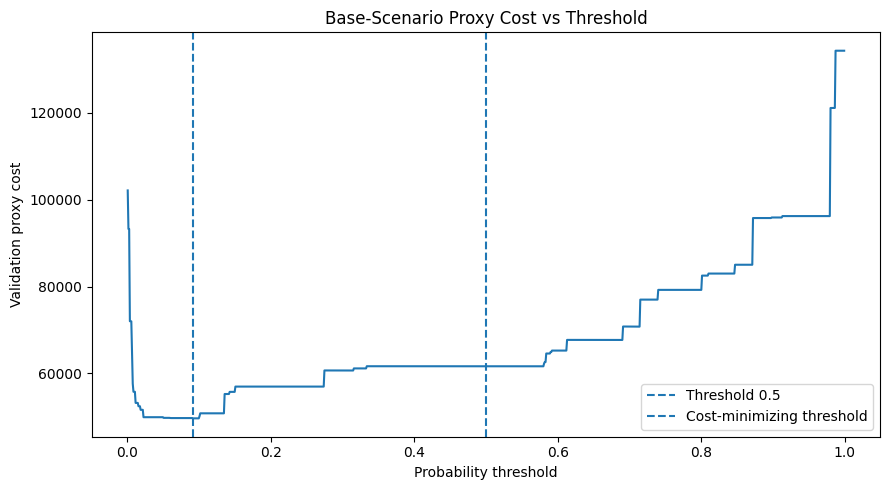

In [21]:
base_threshold_curve = (
    cost_threshold_grid[
        cost_threshold_grid[
            "scenario"
        ] == "base"
    ]
    .copy()
)

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    base_threshold_curve[
        "threshold"
    ],
    base_threshold_curve[
        "total_proxy_cost"
    ]
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Threshold 0.5"
)

plt.axvline(
    base_cost_threshold,
    linestyle="--",
    label="Cost-minimizing threshold"
)

plt.xlabel(
    "Probability threshold"
)

plt.ylabel(
    "Validation proxy cost"
)

plt.title(
    "Base-Scenario Proxy Cost vs Threshold"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "cost_vs_threshold.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 20. Visualize Best Threshold by Cost Scenario

If the best threshold changes across scenarios, the operating policy is sensitive to economic assumptions.

That is important information, not a weakness of the analysis.

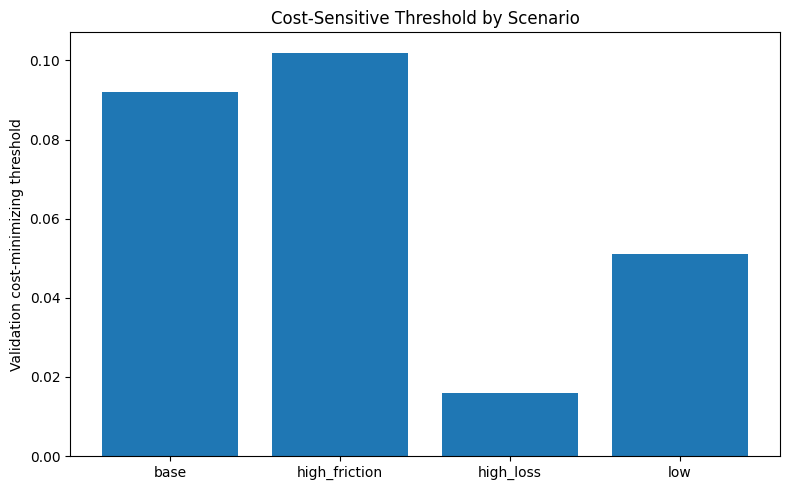

In [22]:
scenario_plot = (
    best_threshold_by_scenario[
        [
            "scenario",
            "threshold"
        ]
    ]
    .copy()
)

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    scenario_plot[
        "scenario"
    ],
    scenario_plot[
        "threshold"
    ]
)

plt.ylabel(
    "Validation cost-minimizing threshold"
)

plt.title(
    "Cost-Sensitive Threshold by Scenario"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "cost_threshold_by_scenario.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 21. Visualize Base-Scenario Policy Costs

This figure compares the total proxy cost of the main Validation policies.

Again, the values are meaningful only under the stated assumptions.

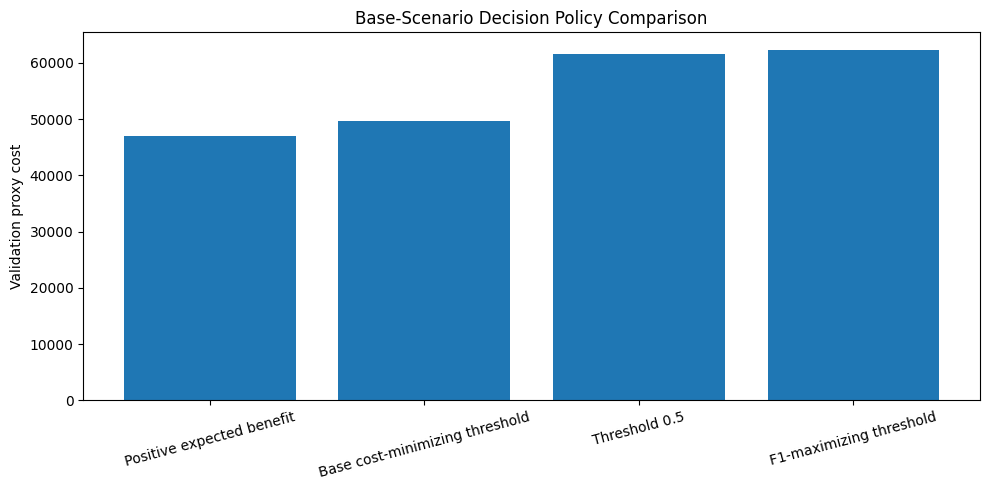

In [23]:
plt.figure(
    figsize=(10, 5)
)

plt.bar(
    policy_comparison[
        "policy"
    ],
    policy_comparison[
        "total_proxy_cost"
    ]
)

plt.ylabel(
    "Validation proxy cost"
)

plt.title(
    "Base-Scenario Decision Policy Comparison"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "threshold_policy_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 22. Inspect the Alert / Recall Trade-off Across Thresholds

Lower thresholds generally create more alerts and higher Recall.

Higher thresholds generally reduce operational burden but miss more fraud.

Notebook 08 will make this capacity constraint explicit with daily Top-K alerting.

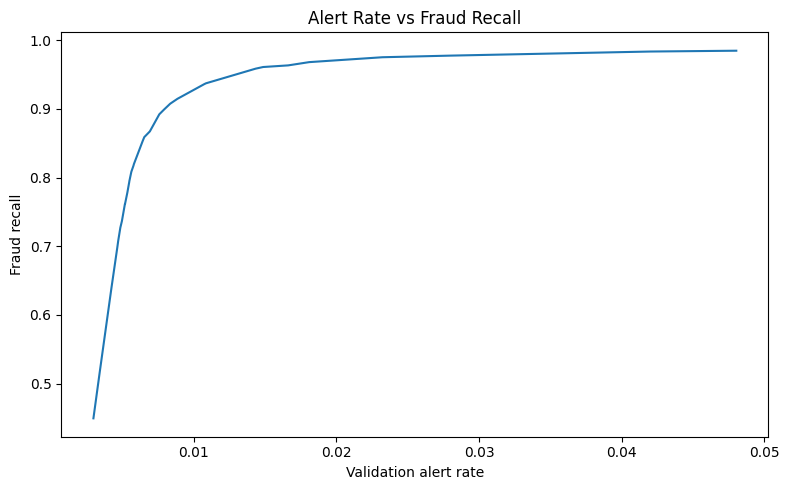

In [24]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    base_threshold_curve[
        "alert_rate"
    ],
    base_threshold_curve[
        "recall"
    ]
)

plt.xlabel(
    "Validation alert rate"
)

plt.ylabel(
    "Fraud recall"
)

plt.title(
    "Alert Rate vs Fraud Recall"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "alert_rate_vs_recall.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 23. Save Validation-Level Decision Details

We save:

- selected calibrated probability
- transaction amount
- expected benefit
- alert decisions for each main policy

This makes the decision analysis auditable.

No Test probability or Test decision is saved here.

In [25]:
validation_decisions = validation[
    [
        "trans_num",
        "trans_date_trans_time",
        "cc_num",
        "merchant_clean",
        "is_fraud",
        "amt",
    ]
].copy()

validation_decisions[
    "selected_probability"
] = validation_probability

validation_decisions[
    "expected_benefit_base"
] = validation_expected_benefit

validation_decisions[
    "alert_threshold_0_5"
] = alert_05

validation_decisions[
    "alert_f1_threshold"
] = alert_f1

validation_decisions[
    "alert_base_cost_threshold"
] = alert_cost

validation_decisions[
    "alert_positive_expected_benefit"
] = expected_benefit_alert

display(
    validation_decisions.head()
)

,trans_num,trans_date_trans_time,cc_num,merchant_clean,is_fraud,amt,selected_probability,expected_benefit_base,alert_threshold_0_5,alert_f1_threshold,alert_base_cost_threshold,alert_positive_expected_benefit
973144,4b76605c3b0d1af2eb0c4d65471a8507,2020-01-29 03:06:41,30234966027947,Hamill-Daugherty,0,64.480000,0.000000,-12.000000,0,0,0,0
973145,4bf9edc93a30609997e20b51463f235f,2020-01-29 03:08:10,30044330818990,Herzog Ltd,0,105.470000,0.000000,-12.000000,0,0,0,0
973146,0f954e9f95faf5c8c2fee730fd15f33c,2020-01-29 03:09:14,4464457352619,"Christiansen, Goyette and Schamberger",0,78.150000,0.000000,-12.000000,0,0,0,0
973147,77ae0fef10fe571fd75ce0bceac1cd68,2020-01-29 03:09:50,377993105397617,Friesen-Stamm,0,64.900000,0.000000,-12.000000,0,0,0,0
973148,8b60b26dee5e2e4a7d212b02ace322c5,2020-01-29 03:10:44,4169388510116,Prohaska-Murray,0,60.890000,0.000000,-12.000000,0,0,0,0


## 24. Save Cost-Decision Configuration

The configuration file records:

- selected imbalance strategy
- selected calibration method
- base cost threshold
- F1 threshold
- base scenario assumptions
- no-alert proxy-cost reference

This helps make the analysis reproducible.

In [26]:
cost_configuration_rows = [
    {
        "setting": "selected_imbalance_strategy",
        "value": selected_strategy,
    },
    {
        "setting": "selected_calibration_method",
        "value": selected_calibration_method,
    },
    {
        "setting": "base_cost_threshold",
        "value": base_cost_threshold,
    },
    {
        "setting": "f1_threshold",
        "value": f1_threshold,
    },
    {
        "setting": "base_no_alert_proxy_cost",
        "value": no_alert_cost,
    },
]

for key, value in BASE_COST.items():
    cost_configuration_rows.append({
        "setting": f"base_{key}",
        "value": value,
    })

cost_configuration = pd.DataFrame(
    cost_configuration_rows
)

display(
    cost_configuration
)

,setting,value
0,selected_imbalance_strategy,Unweighted LightGBM
1,selected_calibration_method,Isotonic
2,base_cost_threshold,0.092000
3,f1_threshold,0.581109
4,base_no_alert_proxy_cost,"236,466.030000"
5,base_loss_rate,0.500000
6,base_incident_cost,10.000000
7,base_review_cost,2.000000
8,base_friction_cost,10.000000
9,base_intervention_effectiveness,0.850000


## 25. Save Results

### Results

- `cost_threshold_grid.csv`
- `cost_sensitivity_results.csv`
- `cost_policy_comparison.csv`
- `cost_scenario_parameters.csv`
- `cost_configuration.csv`
- `cost_validation_decisions.csv`
- `cost_imbalance_selection_check.csv`
- `cost_calibration_selection_check.csv`

### Figures

- `cost_vs_threshold.png`
- `cost_threshold_by_scenario.png`
- `threshold_policy_comparison.png`
- `alert_rate_vs_recall.png`

In [27]:
cost_threshold_grid.to_csv(
    "/kaggle/working/results/"
    "cost_threshold_grid.csv",
    index=False
)

best_threshold_by_scenario.to_csv(
    "/kaggle/working/results/"
    "cost_sensitivity_results.csv",
    index=False
)

policy_comparison.to_csv(
    "/kaggle/working/results/"
    "cost_policy_comparison.csv",
    index=False
)

cost_scenario_table.to_csv(
    "/kaggle/working/results/"
    "cost_scenario_parameters.csv",
    index=False
)

cost_configuration.to_csv(
    "/kaggle/working/results/"
    "cost_configuration.csv",
    index=False
)

validation_decisions.to_csv(
    "/kaggle/working/results/"
    "cost_validation_decisions.csv",
    index=False
)

imbalance_selection.to_csv(
    "/kaggle/working/results/"
    "cost_imbalance_selection_check.csv",
    index=False
)

calibration_selection.to_csv(
    "/kaggle/working/results/"
    "cost_calibration_selection_check.csv",
    index=False
)

print("Results:")
for filename in sorted(
    os.listdir(
        "/kaggle/working/results"
    )
):
    print("-", filename)

print("\nFigures:")
for filename in sorted(
    os.listdir(
        "/kaggle/working/figures"
    )
):
    print("-", filename)

Results:
- cost_calibration_selection_check.csv
- cost_configuration.csv
- cost_imbalance_selection_check.csv
- cost_policy_comparison.csv
- cost_scenario_parameters.csv
- cost_sensitivity_results.csv
- cost_threshold_grid.csv
- cost_validation_decisions.csv

Figures:
- alert_rate_vs_recall.png
- cost_threshold_by_scenario.png
- cost_vs_threshold.png
- threshold_policy_comparison.png


## 26. How to Interpret the Results

### Threshold 0.5

This is a convenient statistical convention, not a business-optimal fraud rule.

### F1-maximizing threshold

This balances Precision and Recall but ignores transaction amount and operating cost.

### Cost-minimizing threshold

This directly optimizes the stated proxy-cost assumptions on Validation.

Its value can move substantially when the assumed costs change.

### Positive expected-benefit rule

This allows the decision to depend on both:

- fraud probability
- transaction amount

A higher-value transaction can justify intervention at a lower fraud probability than a low-value transaction.

That makes this rule conceptually different from one global probability threshold.

## 27. Why Cost Sensitivity Is Essential

Without real operational cost data, reporting one "optimal" threshold would create false precision.

The scenario analysis shows how policy changes when assumptions change.

That is more defensible than pretending the chosen costs are known.

In a real deployment, the scenario parameters should be replaced by empirically estimated quantities such as:

- average review labor cost
- false-decline customer impact
- recovered fraud amount
- chargeback exposure
- intervention success rate

## 28. Leakage and Methodology Notes

### Train

Used to fit preprocessing and the underlying fraud model.

### Calibration

Used to fit probability calibrators.

### Validation

Used to:

- select imbalance strategy
- select calibration method
- select F1 threshold
- select proxy-cost threshold
- compare decision policies

### Test

Remains untouched.

### Cost assumptions are not labels

The scenario parameters are analyst-defined assumptions.

They are not estimated from Test performance.

### Amount is a proxy

`amt` should be described as potential transaction exposure, not actual realized loss.

## 29. Limitations

### Synthetic data

Sparkov is synthetic.

The estimated proxy-cost improvement applies only to this simulator under the stated assumptions.

### Illustrative economics

The project does not observe actual:

- loss given fraud
- review labor cost
- customer-friction cost
- recovery rate
- intervention effectiveness

### Threshold overfitting

The cost threshold is optimized on Validation.

This is why the final Test period must remain untouched until all development decisions are frozen.

### One-period validation

Cost-optimal thresholds can drift over time.

Notebook 09 will examine temporal performance stability.

## Conclusion

This notebook converted calibrated fraud probabilities into cost-sensitive decision policies.

The workflow:

1. recreated the fixed temporal split
2. recreated current + past-only features
3. reproduced imbalance-strategy selection
4. reproduced calibration-method selection
5. defined transparent proxy-cost components
6. evaluated multiple cost scenarios
7. searched Validation thresholds
8. selected a base cost-minimizing threshold
9. selected an F1 reference threshold
10. implemented a transaction-level positive expected-benefit rule
11. compared proxy cost, Precision, Recall, alert rate, and fraud amount recall
12. saved all assumptions and decisions
13. kept the Test period untouched

## Next Notebook

`08_sparkov_alert_capacity.ipynb`

The next notebook will make operational capacity explicit by comparing policies such as:

- daily Top-5
- daily Top-10
- daily Top-25
- daily Top-50
- expected-benefit Top-K

The goal is to understand how much fraud can be captured when investigators can review only a limited number of alerts per day.